In [1]:
# Import necessary libraries
from google.cloud import bigquery
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)
from sklearn.linear_model import LogisticRegression

import lightgbm as lgb
import joblib
import json
from pathlib import Path

In [2]:
# Set up BigQuery client
PROJECT_ID = "amex-46887"
DATASET_ID = "amex_risk"

client = bigquery.Client(project=PROJECT_ID)

In [3]:
# Load model dataset
query = f"""
SELECT *
FROM `{PROJECT_ID}.{DATASET_ID}.model_dataset_v1`
"""

df = client.query(query).to_dataframe()
df.head()

,customer_ID,target,n_statements,P_2_avg,P_2_min,P_2_max,P_2_std,P_2_nulls,D_39_avg,D_39_min,...,B_9_delta,R_1_first,R_1_last,R_1_delta,B_11_first,B_11_last,B_11_delta,S_3_first,S_3_last,S_3_delta
0,0d5b0ad7791ac6950a6108c443191cb7eba5cb56448bd6...,1,1,0.593964,0.593964,0.593964,NaN,0,0.066382,0.066382,...,0.0,0.000289,0.000289,0.0,0.171703,0.171703,0.0,0.386965,0.386965,0.0
1,a129feb6d5195cbe0e9eb0d5b555475973722c0a47a4cf...,1,1,0.402696,0.402696,0.402696,NaN,0,0.009724,0.009724,...,0.0,0.006187,0.006187,0.0,0.075602,0.075602,0.0,0.183267,0.183267,0.0
2,27058659c1b6492f7e840f78a8e71f7224e50adc707a58...,0,1,0.414168,0.414168,0.414168,NaN,0,0.123768,0.123768,...,0.0,0.001974,0.001974,0.0,0.117749,0.117749,0.0,0.547236,0.547236,0.0
3,a37067bc1bf81157ee70cd552cef5c0f74a69865e4ea8d...,0,1,NaN,NaN,NaN,NaN,1,0.007059,0.007059,...,0.0,0.003148,0.003148,0.0,0.146691,0.146691,0.0,0.169028,0.169028,0.0
4,db73185566ecb776b05bb84d66e3aa74b7c887d40d4b8c...,0,1,0.534727,0.534727,0.534727,NaN,0,0.002853,0.002853,...,0.0,0.005323,0.005323,0.0,0.006909,0.006909,0.0,0.159180,0.159180,0.0


In [4]:
# Shape and missing values
print(df.shape)
display(df["target"].value_counts())
display(df.isnull().sum().sort_values(ascending=False).head(20))

(458913, 51)


target
0    340085
1    118828
Name: count, dtype: Int64

S_3_delta      108758
S_3_first       85940
S_3_last        84970
S_3_std         63446
S_3_max         56596
S_3_min         56596
S_3_avg         56596
P_2_delta       18022
P_2_first       17498
P_2_std          7829
R_1_std          5120
D_39_std         5120
B_11_std         5120
B_9_std          5120
P_2_last         2969
P_2_min          2434
P_2_max          2434
P_2_avg          2434
customer_ID         0
R_1_avg             0
dtype: int64

In [5]:
# Feature and target
X = df.drop(columns=["customer_ID", "target"])
y = df["target"]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (458913, 49)
Target shape: (458913,)


In [6]:
# Train/validation split
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_valid:", X_valid.shape)

X_train: (367130, 49)
X_valid: (91783, 49)


In [7]:
# Logistic Regression baseline
log_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

log_model.fit(X_train, y_train)
log_pred_proba = log_model.predict_proba(X_valid)[:, 1]
log_pred = (log_pred_proba >= 0.5).astype(int)

print("Logistic ROC-AUC:", roc_auc_score(y_valid, log_pred_proba))
print("Logistic Accuracy:", accuracy_score(y_valid, log_pred))
print("Logistic Precision:", precision_score(y_valid, log_pred))
print("Logistic Recall:", recall_score(y_valid, log_pred))
print("Logistic F1:", f1_score(y_valid, log_pred))

Logistic ROC-AUC: 0.9419294851304871
Logistic Accuracy: 0.8781909503938637
Logistic Precision: 0.7896796170134414
Logistic Recall: 0.7218295043339225
Logistic F1: 0.7542316992745658


In [8]:
# LightGBM model
lgb_model = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42
)

lgb_model.fit(X_train, y_train)
lgb_pred_proba = lgb_model.predict_proba(X_valid)[:, 1]
lgb_pred = (lgb_pred_proba >= 0.5).astype(int)

print("LightGBM ROC-AUC:", roc_auc_score(y_valid, lgb_pred_proba))
print("LightGBM Accuracy:", accuracy_score(y_valid, lgb_pred))
print("LightGBM Precision:", precision_score(y_valid, lgb_pred))
print("LightGBM Recall:", recall_score(y_valid, lgb_pred))
print("LightGBM F1:", f1_score(y_valid, lgb_pred))

[LightGBM] [Info] Number of positive: 95062, number of negative: 272068
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.040032 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 10752
[LightGBM] [Info] Number of data points in the train set: 367130, number of used features: 45
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.258933 -> initscore=-1.051523
[LightGBM] [Info] Start training from score -1.051523
LightGBM ROC-AUC: 0.9477833507055811
LightGBM Accuracy: 0.8853273482017368
LightGBM Precision: 0.7847404412713431
LightGBM Recall: 0.7677354203483969
LightGBM F1: 0.7761447986898355


In [9]:
# Compare models
metrics_df = pd.DataFrame([
    {
        "model": "Logistic Regression",
        "roc_auc": roc_auc_score(y_valid, log_pred_proba),
        "accuracy": accuracy_score(y_valid, log_pred),
        "precision": precision_score(y_valid, log_pred),
        "recall": recall_score(y_valid, log_pred),
        "f1": f1_score(y_valid, log_pred),
    },
    {
        "model": "LightGBM",
        "roc_auc": roc_auc_score(y_valid, lgb_pred_proba),
        "accuracy": accuracy_score(y_valid, lgb_pred),
        "precision": precision_score(y_valid, lgb_pred),
        "recall": recall_score(y_valid, lgb_pred),
        "f1": f1_score(y_valid, lgb_pred),
    }
])

metrics_df.sort_values("roc_auc", ascending=False)

,model,roc_auc,accuracy,precision,recall,f1
1,LightGBM,0.947783,0.885327,0.78474,0.767735,0.776145
0,Logistic Regression,0.941929,0.878191,0.78968,0.721830,0.754232


In [10]:
# Detailed LightGBM report
print(confusion_matrix(y_valid, lgb_pred))
print(classification_report(y_valid, lgb_pred))

[[63012  5005]
 [ 5520 18246]]
              precision    recall  f1-score   support

         0.0       0.92      0.93      0.92     68017
         1.0       0.78      0.77      0.78     23766

    accuracy                           0.89     91783
   macro avg       0.85      0.85      0.85     91783
weighted avg       0.88      0.89      0.88     91783



In [11]:
Path("../models").mkdir(exist_ok=True)

joblib.dump(lgb_model, "../models/best_model.pkl")
joblib.dump(list(X.columns), "../models/feature_columns.pkl")

metrics = {
    "logistic_regression": {
        "roc_auc": float(roc_auc_score(y_valid, log_pred_proba)),
        "accuracy": float(accuracy_score(y_valid, log_pred)),
        "precision": float(precision_score(y_valid, log_pred)),
        "recall": float(recall_score(y_valid, log_pred)),
        "f1": float(f1_score(y_valid, log_pred)),
    },
    "lightgbm": {
        "roc_auc": float(roc_auc_score(y_valid, lgb_pred_proba)),
        "accuracy": float(accuracy_score(y_valid, lgb_pred)),
        "precision": float(precision_score(y_valid, lgb_pred)),
        "recall": float(recall_score(y_valid, lgb_pred)),
        "f1": float(f1_score(y_valid, lgb_pred)),
    }
}

with open("../models/metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

print("Artifacts saved successfully.")

Artifacts saved successfully.


In [12]:
thresholds = np.arange(0.1, 0.9, 0.05)

results = []

for t in thresholds:
    preds = (lgb_pred_proba >= t).astype(int)

    results.append({
        "threshold": t,
        "precision": precision_score(y_valid, preds),
        "recall": recall_score(y_valid, preds),
        "f1": f1_score(y_valid, preds)
    })

threshold_df = pd.DataFrame(results)
threshold_df

,threshold,precision,recall,f1
0,0.10,0.574380,0.965034,0.720139
1,0.15,0.611689,0.949424,0.744023
2,0.20,0.642515,0.932088,0.760675
3,0.25,0.669952,0.912354,0.772586
4,0.30,0.695442,0.889127,0.780447
5,0.35,0.718047,0.863040,0.783895
6,0.40,0.741378,0.835774,0.785751
7,0.45,0.763210,0.803417,0.782798
8,0.50,0.784740,0.767735,0.776145
9,0.55,0.807522,0.728183,0.765803


<Axes: xlabel='threshold'>

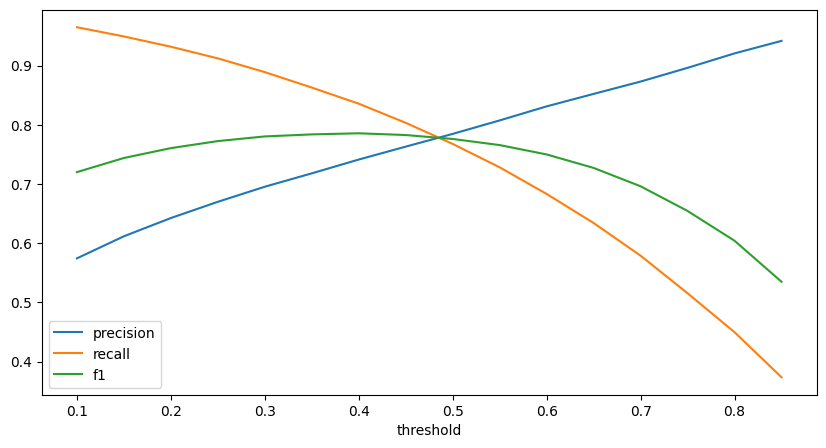

In [13]:
threshold_df.plot(x="threshold", y=["precision", "recall", "f1"], figsize=(10,5))

In [14]:
def risk_band(score):
    if score < 0.2:
        return "Low"
    elif score < 0.5:
        return "Medium"
    elif score < 0.8:
        return "High"
    else:
        return "Critical"

In [15]:
df_valid = X_valid.copy()
df_valid["target"] = y_valid
df_valid["risk_score"] = lgb_pred_proba
df_valid["risk_band"] = df_valid["risk_score"].apply(risk_band)

df_valid[["risk_score", "risk_band"]].head()

,risk_score,risk_band
457042,0.241044,Medium
36321,0.001357,Low
198248,0.128647,Low
45454,0.008623,Low
233713,0.045563,Low


In [17]:
# Feature importance

importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": lgb_model.feature_importances_
}).sort_values("importance", ascending=False)

importance_df.head(20)

,feature,importance
32,P_2_last,556
44,B_11_last,493
26,S_3_avg,346
35,D_39_last,337
47,S_3_last,312
33,P_2_delta,296
38,B_9_last,291
4,P_2_std,288
8,D_39_max,270
1,P_2_avg,234


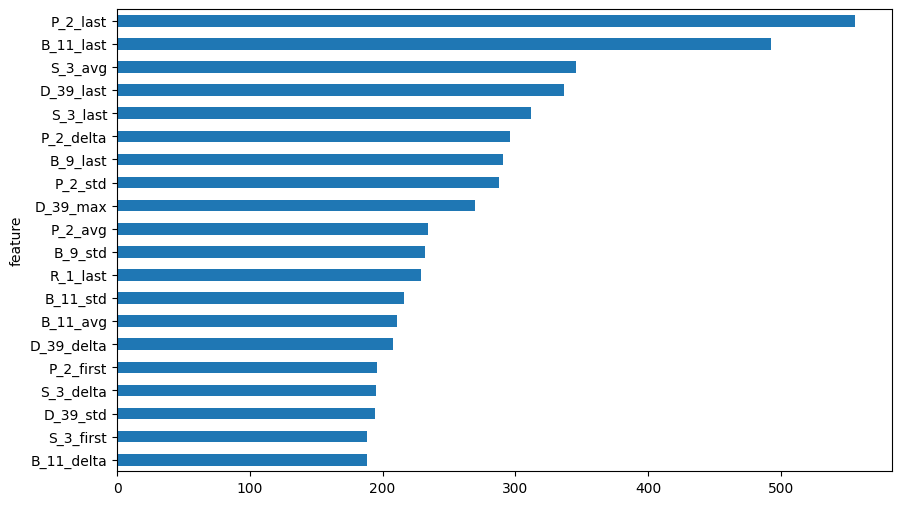

In [19]:
# Plot feature importance
importance_df.head(20).plot(
    kind="barh",
    x="feature",
    y="importance",
    figsize=(10,6),
    legend=False
)
plt.gca().invert_yaxis()